# Low-Resolution Shift-Center Nearest-Neighbor Vecchia Simulation

Simulation-only diagnostic for advection-aware budget reduction. The standard baseline uses local lagged neighbors with `A/B/C = 20/18/15`. The proposed model keeps the current-time nearest neighbors, but at lagged times it centers a fresh nearest-neighbor search at the known upstream locations: `t-1` shifted east by `0.126` and `t-2` shifted east by `0.252`.

The key question is whether shift-centered lag neighborhoods can recover the temporal/advection parameters with a smaller lag budget than the best local-only reduced baseline.


In [1]:
import os
import sys
import time
import io
import contextlib
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.fft
import matplotlib.pyplot as plt

AMAREL_SRC = "/home/jl2815/tco"
LOCAL_SRC = "/Users/joonwonlee/Documents/GEMS_TCO-1/src"
_src = AMAREL_SRC if os.path.exists(AMAREL_SRC) else LOCAL_SRC
sys.path.insert(0, _src)

from GEMS_TCO import kernels_vecchia
from GEMS_TCO import kernels_vecchia_advec
from GEMS_TCO import orderings as _orderings

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float64

# Low-resolution shift-center nearest-neighbor test: lat x4, lon x2.
DELTA_LAT = 0.044 * 4
DELTA_LON = 0.063 * 2
T_STEPS = 8

print("DEVICE:", DEVICE)
print("SRC:", _src)
print("Grid resolution:", DELTA_LAT, DELTA_LON)



DEVICE: cpu
SRC: /Users/joonwonlee/Documents/GEMS_TCO-1/src
Grid resolution: 0.176 0.126


## Settings And Model Groups


In [2]:
LAT_RANGE = (-3.0, 2.0)
LON_RANGE = (121.0, 131.0)
MC_NUM_ITERS = 30
SEED = 42

SMOOTH = 0.5
MM_COND_NUMBER = 100
NHEADS = 0
DAILY_STRIDE = 2

LBFGS_STEPS = 5
LBFGS_EVAL = 20
LBFGS_HIST = 10
INIT_NOISE = 0.7
SUPPRESS_FIT_PRINTS = True

RUN_ONE_SHOT_GODAMBE = True
HESSIAN_EPS = 1e-4
SCORE_EPS = 1e-5
H_RIDGE_SCALE = 1e-6
GODAMBE_J_METHOD = "block"
GODAMBE_BLOCK_LAT_WIDTH = 0.50
GODAMBE_BLOCK_LON_WIDTH = 0.50
GODAMBE_BLOCK_TIME_WIDTH = 2.0

TRUE_DICT = {
    "sigmasq": 10.0,
    "range_lat": 0.30,
    "range_lon": 0.40,
    "range_time": 2.0,
    "advec_lat": 0.08,
    "advec_lon": -0.126,
    "nugget": 2.5,
}

# True advec_lon is negative, so the upstream location at previous times is eastward.
TRUE_LAG1_LON_SHIFT = abs(TRUE_DICT["advec_lon"])
TRUE_LAG2_LON_SHIFT = 2.0 * abs(TRUE_DICT["advec_lon"])
print(f"lon step = {DELTA_LON:.3f}; lag1 true lon shift = {TRUE_LAG1_LON_SHIFT:.3f} ({TRUE_LAG1_LON_SHIFT / DELTA_LON:.1f} cells)")
print(f"lag2 true lon shift = {TRUE_LAG2_LON_SHIFT:.3f} ({TRUE_LAG2_LON_SHIFT / DELTA_LON:.1f} cells)")

BASE_A, BASE_B, BASE_C = 20, 18, 15
CAND_A, CAND_B, CAND_C = 20, 16, 10

def total_conditioning_std(a, b=0, c=0, uses_lag2=True):
    total = int(a) + int(1 + b)
    if uses_lag2:
        total += int(1 + c)
    return total

def total_conditioning_advec_center(a, b=0, c=0, uses_lag2=True):
    # kernels_vecchia_advec uses same-location + shifted-center slots at each lag.
    total = int(a) + int(1 + b + 1)
    if uses_lag2:
        total += int(1 + c + 1)
    return total

def std_spec(name, a, b, c, group, allocation, daily_stride=DAILY_STRIDE, uses_lag2=True):
    return {
        "name": name,
        "group": group,
        "kernel": "std",
        "limit_A": int(a),
        "limit_B": int(b),
        "limit_C": int(c),
        "daily_stride": int(daily_stride),
        "uses_lag2": bool(uses_lag2),
        "advec_lon_offset": 0.0,
        "lag1_lon_shift": 0.0,
        "lag2_lon_shift": 0.0,
        "lag1_ratio_actual": float(b / a) if a else np.nan,
        "lag2_ratio_actual": float(c / a) if (a and uses_lag2) else 0.0,
        "total_conditioning": total_conditioning_std(a, b, c, uses_lag2=uses_lag2),
        "allocation": allocation,
        "description": f"t: {a}; t-1: same loc + {b} local; t-2: same loc + {c} local",
    }

def advec_center_spec(name, a, b, c, group, allocation, daily_stride=DAILY_STRIDE):
    return {
        "name": name,
        "group": group,
        "kernel": "advec_center",
        "limit_A": int(a),
        "limit_B": int(b),
        "limit_C": int(c),
        "daily_stride": int(daily_stride),
        "uses_lag2": True,
        "advec_lon_offset": TRUE_LAG1_LON_SHIFT,
        "lag1_lon_shift": TRUE_LAG1_LON_SHIFT,
        "lag2_lon_shift": TRUE_LAG2_LON_SHIFT,
        "lag1_ratio_actual": float(b / a) if a else np.nan,
        "lag2_ratio_actual": float(c / a) if a else np.nan,
        "total_conditioning": total_conditioning_advec_center(a, b, c, uses_lag2=True),
        "allocation": allocation,
        "description": f"t: {a}; t-1: same loc + shifted center + {b} NN around shifted center; t-2: same loc + shifted center + {c} NN around shifted center",
    }

EXPERIMENT_GROUPS = {
    "shift_center_nn": [
        std_spec(
            "BaseLocal_A20_B18_C15", BASE_A, BASE_B, BASE_C,
            "shift_center_nn", "best local-only reduced baseline: 20/18/15",
        ),
        std_spec(
            "StdLocal_A20_B16_C10", CAND_A, CAND_B, CAND_C,
            "shift_center_nn", "local-only aggressive reduction control: 20/16/10",
        ),
        advec_center_spec(
            "ShiftCenterNN_A20_B16_C10", CAND_A, CAND_B, CAND_C,
            "shift_center_nn", "fresh lagged NN search around true upstream centers",
        ),
    ]
}

ACTIVE_GROUPS = ["shift_center_nn"]

MODEL_SPECS = {}
for group_name in ACTIVE_GROUPS:
    for spec in EXPERIMENT_GROUPS[group_name]:
        key = f"{group_name}::{spec['name']}"
        MODEL_SPECS[key] = spec

spec_df = pd.DataFrame(MODEL_SPECS).T
print("Active groups:", ACTIVE_GROUPS)
print("Number of model fits per MC iteration:", len(MODEL_SPECS))
display(spec_df[["group", "kernel", "limit_A", "limit_B", "limit_C", "advec_lon_offset", "lag1_lon_shift", "lag2_lon_shift", "daily_stride", "allocation", "lag1_ratio_actual", "lag2_ratio_actual", "total_conditioning", "description"]])


lon step = 0.126; lag1 true lon shift = 0.126 (1.0 cells)
lag2 true lon shift = 0.252 (2.0 cells)
Active groups: ['shift_center_nn']
Number of model fits per MC iteration: 3


,group,kernel,limit_A,limit_B,limit_C,advec_lon_offset,lag1_lon_shift,lag2_lon_shift,daily_stride,allocation,lag1_ratio_actual,lag2_ratio_actual,total_conditioning,description
shift_center_nn::BaseLocal_A20_B18_C15,shift_center_nn,std,20,18,15,0.0,0.0,0.0,2,best local-only reduced baseline: 20/18/15,0.9,0.75,55,t: 20; t-1: same loc + 18 local; t-2: same loc...
shift_center_nn::StdLocal_A20_B16_C10,shift_center_nn,std,20,16,10,0.0,0.0,0.0,2,local-only aggressive reduction control: 20/16/10,0.8,0.5,48,t: 20; t-1: same loc + 16 local; t-2: same loc...
shift_center_nn::ShiftCenterNN_A20_B16_C10,shift_center_nn,advec_center,20,16,10,0.126,0.126,0.252,2,fresh lagged NN search around true upstream ce...,0.8,0.5,50,t: 20; t-1: same loc + shifted center + 16 NN ...


## Boundary-Aware Shift-Center Kernel


In [3]:
class fit_vecchia_lbfgs_shift_center_nn(kernels_vecchia_advec.fit_vecchia_lbfgs_advec):
    """Shift-center NN variant with same-location fallback outside the observed lon range."""

    def _build_advec_lookup(self, n_points):
        from sklearn.neighbors import BallTree

        if self.spatial_coords is not None:
            coords_np = np.asarray(self.spatial_coords[:n_points], dtype=np.float64)
        else:
            all_data = [torch.from_numpy(d) if isinstance(d, np.ndarray) else d
                        for d in self.input_map.values()]
            coords_raw = all_data[0][:n_points, :2].cpu().numpy().astype(np.float64)
            nan_mask = np.isnan(coords_raw).any(axis=1)
            coords_np = coords_raw.copy()
            coords_np[nan_mask] = np.array([0.0, 1000.0])

        tree = BallTree(np.radians(coords_np), metric="haversine")
        lats = coords_np[:, 0]
        lons = coords_np[:, 1]
        valid = ~np.isnan(coords_np).any(axis=1)
        lon_min = float(np.nanmin(lons[valid]))
        lon_max = float(np.nanmax(lons[valid]))

        def query_shift(mult):
            shifted_lons = lons + mult * self.advec_lon_offset
            outside = (~valid) | (shifted_lons < lon_min) | (shifted_lons > lon_max)
            q = np.column_stack([np.radians(lats), np.radians(shifted_lons)])
            _, idx = tree.query(q, k=1)
            out = idx.flatten().astype(np.int64)
            # If the true upstream point leaves the observed grid, use the same location.
            out[outside] = np.arange(n_points, dtype=np.int64)[outside]
            return out

        return query_shift(1.0), query_shift(2.0)


## Simulation Helpers


In [4]:
P_LABELS = ["sigmasq", "range_lat", "range_lon", "range_time", "advec_lat", "advec_lon", "nugget"]
P_COLS = ["sigmasq_est", "range_lat_est", "range_lon_est", "range_t_est", "advec_lat_est", "advec_lon_est", "nugget_est"]
SPATIAL_KEYS = ["sigmasq", "range_lat", "range_lon"]
ADVECTION_KEYS = ["advec_lat", "advec_lon"]

def transform_log_phi_to_physical(p):
    phi1, phi2, phi3, phi4 = (torch.exp(p[i]) for i in range(4))
    rlon = 1.0 / phi2
    return torch.stack([
        phi1 / phi2,
        rlon / torch.sqrt(phi3),
        rlon,
        rlon / torch.sqrt(phi4),
        p[4],
        p[5],
        torch.exp(p[6]),
    ])

def get_covariance_on_grid(lx, ly, lt, params):
    params = torch.clamp(params, min=-15.0, max=15.0)
    phi1, phi2, phi3, phi4 = (torch.exp(params[i]) for i in range(4))
    u_lat = lx - params[4] * lt
    u_lon = ly - params[5] * lt
    dist = torch.sqrt(u_lat.pow(2) * phi3 + u_lon.pow(2) + lt.pow(2) * phi4 + 1e-8)
    return (phi1 / phi2) * torch.exp(-dist * phi2)

def build_target_grid(lat_range, lon_range):
    lat0, lat1 = float(min(lat_range)), float(max(lat_range))
    lon0, lon1 = float(min(lon_range)), float(max(lon_range))
    n_lat = int(np.floor((lat1 - lat0) / DELTA_LAT + 1e-9)) + 1
    n_lon = int(np.floor((lon1 - lon0) / DELTA_LON + 1e-9)) + 1
    lats = lat0 + torch.arange(n_lat, device=DEVICE, dtype=DTYPE) * DELTA_LAT
    lons = lon0 + torch.arange(n_lon, device=DEVICE, dtype=DTYPE) * DELTA_LON
    lats = torch.round(lats * 10000) / 10000
    lons = torch.round(lons * 10000) / 10000
    g_lat, g_lon = torch.meshgrid(lats, lons, indexing="ij")
    grid_coords = torch.stack([g_lat.flatten(), g_lon.flatten()], dim=1)
    return lats, lons, grid_coords

def grid_resolution_report(lats, lons):
    lat_d = torch.diff(lats).detach().cpu().numpy()
    lon_d = torch.diff(lons).detach().cpu().numpy()
    return {
        "lat_min_step": float(lat_d.min()) if len(lat_d) else np.nan,
        "lat_max_step": float(lat_d.max()) if len(lat_d) else np.nan,
        "lon_min_step": float(lon_d.min()) if len(lon_d) else np.nan,
        "lon_max_step": float(lon_d.max()) if len(lon_d) else np.nan,
        "lat_first_last": (float(lats[0]), float(lats[-1])),
        "lon_first_last": (float(lons[0]), float(lons[-1])),
    }

def generate_field_values(n_lat, n_lon, t_steps, params):
    cpu = torch.device("cpu")
    f32 = torch.float32
    px, py, pt = 2 * n_lat, 2 * n_lon, 2 * t_steps
    lx = torch.arange(px, device=cpu, dtype=f32) * DELTA_LAT
    lx[px // 2:] -= px * DELTA_LAT
    ly = torch.arange(py, device=cpu, dtype=f32) * DELTA_LON
    ly[py // 2:] -= py * DELTA_LON
    lt = torch.arange(pt, device=cpu, dtype=f32)
    lt[pt // 2:] -= pt
    params_cpu = params.cpu().float()
    Lx, Ly, Lt = torch.meshgrid(lx, ly, lt, indexing="ij")
    C = get_covariance_on_grid(Lx, Ly, Lt, params_cpu)
    S = torch.fft.fftn(C)
    S.real = torch.clamp(S.real, min=0)
    noise = torch.fft.fftn(torch.randn(px, py, pt, device=cpu, dtype=f32))
    field = torch.fft.ifftn(torch.sqrt(S.real) * noise).real[:n_lat, :n_lon, :t_steps]
    return field.to(device=DEVICE, dtype=DTYPE)

def assemble_reg_map(field, grid_coords, true_params, t_offset=21.0):
    nugget_std = torch.sqrt(torch.exp(true_params[6]))
    n_grid = grid_coords.shape[0]
    field_flat = field.reshape(n_grid, field.shape[-1])
    reg_map = {}
    for t_idx in range(field.shape[-1]):
        key = f"t{t_idx}"
        t_val = float(t_offset + t_idx)
        dummy = torch.zeros(7, device=DEVICE, dtype=DTYPE)
        if t_idx > 0:
            dummy[t_idx - 1] = 1.0
        rows = torch.zeros((n_grid, 11), device=DEVICE, dtype=DTYPE)
        rows[:, :2] = grid_coords
        rows[:, 2] = field_flat[:, t_idx] + torch.randn(n_grid, device=DEVICE, dtype=DTYPE) * nugget_std
        rows[:, 3] = t_val
        rows[:, 4:] = dummy.unsqueeze(0).expand(n_grid, -1)
        reg_map[key] = rows.detach()
    return reg_map

def compute_grid_ordering(grid_coords, mm_cond_number):
    coords_np = grid_coords.detach().cpu().numpy()
    ord_mm = _orderings.maxmin_cpp(coords_np)
    nns = _orderings.find_nns_l2(locs=coords_np[ord_mm], max_nn=mm_cond_number)
    return ord_mm, nns

def true_to_log_params(true_dict):
    phi2 = 1.0 / true_dict["range_lon"]
    phi1 = true_dict["sigmasq"] * phi2
    phi3 = (true_dict["range_lon"] / true_dict["range_lat"]) ** 2
    phi4 = (true_dict["range_lon"] / true_dict["range_time"]) ** 2
    return [np.log(phi1), np.log(phi2), np.log(phi3), np.log(phi4), true_dict["advec_lat"], true_dict["advec_lon"], np.log(true_dict["nugget"])]

def backmap_params(out_params):
    p = [x.item() if isinstance(x, torch.Tensor) else float(x) for x in out_params[:7]]
    phi2 = np.exp(p[1])
    phi3 = np.exp(p[2])
    phi4 = np.exp(p[3])
    rlon = 1.0 / phi2
    return {
        "sigmasq": np.exp(p[0]) / phi2,
        "range_lat": rlon / phi3 ** 0.5,
        "range_lon": rlon,
        "range_time": rlon / phi4 ** 0.5,
        "advec_lat": p[4],
        "advec_lon": p[5],
        "nugget": np.exp(p[6]),
    }

def rmsre_for_keys(est, true_dict, keys, zero_thresh=0.01):
    vals = []
    for key in keys:
        tv = true_dict[key]
        ev = est[key]
        if abs(tv) >= zero_thresh:
            vals.append(((ev - tv) / abs(tv)) ** 2)
        else:
            vals.append(abs(ev - tv) ** 2)
    return float(np.sqrt(np.mean(vals)))

def relative_se_summary(se_by_key, denom_dict, keys, zero_thresh=0.01):
    vals = []
    for key in keys:
        denom = abs(denom_dict[key])
        if denom >= zero_thresh:
            vals.append((se_by_key[key] / denom) ** 2)
        else:
            vals.append(se_by_key[key] ** 2)
    return float(np.sqrt(np.mean(vals)))

def calculate_metrics(out_params, true_dict):
    est = backmap_params(out_params)
    return {
        "overall_rmsre": rmsre_for_keys(est, true_dict, P_LABELS),
        "spatial_rmsre": rmsre_for_keys(est, true_dict, SPATIAL_KEYS),
        "range_time_re": abs(est["range_time"] - true_dict["range_time"]) / abs(true_dict["range_time"]),
        "advec_rmsre": rmsre_for_keys(est, true_dict, ADVECTION_KEYS),
        "nugget_re": abs(est["nugget"] - true_dict["nugget"]) / abs(true_dict["nugget"]),
        "est": est,
    }

def make_random_init(rng, true_log, init_noise):
    noisy = list(true_log)
    for i in [0, 1, 2, 3, 6]:
        noisy[i] = true_log[i] + rng.uniform(-init_noise, init_noise)
    for i in [4, 5]:
        scale = max(abs(true_log[i]), 0.05)
        noisy[i] = true_log[i] + rng.uniform(-2 * scale, 2 * scale)
    return noisy


## Optional Godambe Helpers


In [5]:
def finite_diff_hessian(nll_fn, p, eps=HESSIAN_EPS):
    n = p.shape[0]
    H = torch.zeros(n, n, device=p.device, dtype=p.dtype)
    for i in range(n):
        p_p = p.detach().clone(); p_m = p.detach().clone()
        p_p[i] += eps; p_m[i] -= eps
        p_p.requires_grad_(True); p_m.requires_grad_(True)
        g_p = torch.autograd.grad(nll_fn(p_p), p_p)[0].detach()
        g_m = torch.autograd.grad(nll_fn(p_m), p_m)[0].detach()
        H[i] = (g_p - g_m) / (2.0 * eps)
    return (H + H.T) / 2.0

def vecchia_per_unit_target_coords(model):
    chunks = []
    if model.Heads_data is not None and model.Heads_data.shape[0] > 0:
        chunks.append(model.Heads_data[:, [0, 1, 3]].to(dtype=DTYPE))
    for X_b in [model.X_A, model.X_AB, model.X_ABC]:
        if X_b is not None and X_b.shape[0] > 0:
            chunks.append(X_b[:, -1, :].to(dtype=DTYPE))
    if not chunks:
        return torch.empty((0, 3), device=DEVICE, dtype=DTYPE)
    return torch.cat(chunks, dim=0)

def make_block_ids(target_coords):
    lat = target_coords[:, 0]
    lon = target_coords[:, 1]
    tim = target_coords[:, 2]
    lat_id = torch.floor((lat - lat.min()) / GODAMBE_BLOCK_LAT_WIDTH).to(torch.long)
    lon_id = torch.floor((lon - lon.min()) / GODAMBE_BLOCK_LON_WIDTH).to(torch.long)
    if GODAMBE_BLOCK_TIME_WIDTH is None or GODAMBE_BLOCK_TIME_WIDTH <= 0:
        time_id = torch.zeros_like(lat_id)
    else:
        time_id = torch.floor((tim - tim.min()) / GODAMBE_BLOCK_TIME_WIDTH).to(torch.long)
    n_lon = int(lon_id.max().item()) + 1 if lon_id.numel() else 1
    n_time = int(time_id.max().item()) + 1 if time_id.numel() else 1
    raw_id = (lat_id * n_lon + lon_id) * n_time + time_id
    _, block_id = torch.unique(raw_id, sorted=True, return_inverse=True)
    return block_id

def score_cov_per_unit_centered(score_mat):
    n_units = score_mat.shape[1]
    score_mean = score_mat.mean(dim=1)
    score_centered = score_mat - score_mean.unsqueeze(1)
    if n_units > 1:
        return score_centered @ score_centered.T / (n_units * (n_units - 1))
    return score_mat @ score_mat.T / max(n_units ** 2, 1)

def score_cov_block_cluster(score_mat, target_coords):
    n_units = score_mat.shape[1]
    scores = score_mat.T.contiguous()
    block_id = make_block_ids(target_coords)
    n_blocks = int(block_id.max().item()) + 1 if block_id.numel() else 0
    block_scores = torch.zeros((n_blocks, scores.shape[1]), device=DEVICE, dtype=DTYPE)
    block_scores.index_add_(0, block_id, scores)
    if n_blocks > 1:
        centered = block_scores - block_scores.mean(dim=0, keepdim=True)
        J = centered.T @ centered * (n_blocks / (n_blocks - 1)) / (n_units ** 2)
    else:
        J = block_scores.T @ block_scores / max(n_units ** 2, 1)
    return J, n_blocks

def compute_vecchia_godambe(model, raw_params):
    p_hat = torch.tensor(raw_params[:7], device=DEVICE, dtype=DTYPE, requires_grad=True)

    def nll(p):
        return model.vecchia_batched_likelihood(p)

    H = finite_diff_hessian(nll, p_hat)
    eig = torch.linalg.eigvalsh(H).detach()
    h_abs_min = torch.clamp(torch.min(torch.abs(eig)), min=1e-12)
    h_cond = float((torch.max(torch.abs(eig)) / h_abs_min).detach().cpu())
    beta_hat = model.get_gls_beta(p_hat).detach()

    def per_unit_losses(p):
        return model.vecchia_per_unit_nll_terms(p, beta_hat)

    cols = []
    for k in range(p_hat.shape[0]):
        pp = p_hat.detach().clone(); pm = p_hat.detach().clone()
        pp[k] += SCORE_EPS; pm[k] -= SCORE_EPS
        with torch.no_grad():
            cols.append((per_unit_losses(pp) - per_unit_losses(pm)) / (2.0 * SCORE_EPS))
    score_mat = torch.stack(cols)
    n_units = score_mat.shape[1]
    target_coords = vecchia_per_unit_target_coords(model)
    if target_coords.shape[0] != n_units:
        raise RuntimeError(f"target/score mismatch: targets={target_coords.shape[0]}, scores={n_units}")

    score_mean = score_mat.mean(dim=1)
    p_grad = p_hat.detach().clone().requires_grad_(True)
    profile_grad = torch.autograd.grad(nll(p_grad), p_grad)[0].detach()
    score_grad_diff = profile_grad - score_mean

    J_uncentered = score_mat @ score_mat.T / (n_units ** 2)
    J_centered = score_cov_per_unit_centered(score_mat)
    J_block, n_blocks = score_cov_block_cluster(score_mat, target_coords)
    if GODAMBE_J_METHOD == "block":
        J_main = J_block
    elif GODAMBE_J_METHOD == "per_unit_centered":
        J_main = J_centered
    elif GODAMBE_J_METHOD == "per_unit_uncentered":
        J_main = J_uncentered
    else:
        raise ValueError(f"Unknown GODAMBE_J_METHOD={GODAMBE_J_METHOD!r}")

    eye = torch.eye(H.shape[0], device=DEVICE, dtype=DTYPE)
    h_scale = torch.clamp(torch.mean(torch.abs(torch.diag(H))), min=1.0)
    H_inv = torch.linalg.pinv(H + eye * h_scale * H_RIDGE_SCALE)
    Jac = torch.autograd.functional.jacobian(transform_log_phi_to_physical, p_hat)

    def summarize_J(J):
        G_raw = H_inv @ J @ H_inv
        G_phys = Jac @ G_raw @ Jac.T
        se = torch.sqrt(torch.clamp(torch.diag(G_phys), min=0.0)).detach().cpu().numpy()
        se_by_key = dict(zip(P_LABELS, [float(x) for x in se]))
        return se_by_key, {
            "spatial": relative_se_summary(se_by_key, TRUE_DICT, SPATIAL_KEYS),
            "overall": relative_se_summary(se_by_key, TRUE_DICT, P_LABELS),
            "advec": relative_se_summary(se_by_key, TRUE_DICT, ADVECTION_KEYS),
            "nugget": se_by_key["nugget"] / abs(TRUE_DICT["nugget"]),
        }

    se_main, rel_main = summarize_J(J_main)
    se_block, rel_block = summarize_J(J_block)
    se_centered, rel_centered = summarize_J(J_centered)
    se_uncentered, rel_uncentered = summarize_J(J_uncentered)
    return {
        "gim_j_method": GODAMBE_J_METHOD,
        "gim_n_units": int(n_units),
        "gim_n_blocks": int(n_blocks),
        "gim_h_cond_abs": h_cond,
        "gim_score_mean_max_abs": float(torch.max(torch.abs(score_mean)).detach().cpu()),
        "gim_profile_grad_max_abs": float(torch.max(torch.abs(profile_grad)).detach().cpu()),
        "gim_score_profile_diff_max_abs": float(torch.max(torch.abs(score_grad_diff)).detach().cpu()),
        "gim_spatial_rel_se": rel_main["spatial"],
        "gim_overall_rel_se": rel_main["overall"],
        "gim_advec_rel_se": rel_main["advec"],
        "gim_nugget_rel_se": rel_main["nugget"],
        "gim_spatial_rel_se_block": rel_block["spatial"],
        "gim_spatial_rel_se_perunit_centered": rel_centered["spatial"],
        "gim_spatial_rel_se_uncentered": rel_uncentered["spatial"],
        **{f"gim_se_{k}": v for k, v in se_main.items()},
    }


## Fit And Monte Carlo


In [6]:
def fit_vecchia_spec(model_key, spec, reg_map_ord, nns_grid, ordered_grid_coords_np, initial_vals, compute_godambe=False):
    params = [torch.tensor([val], device=DEVICE, dtype=DTYPE, requires_grad=True) for val in initial_vals]
    daily_stride = int(spec.get("daily_stride", DAILY_STRIDE))
    if spec["kernel"] == "std":
        model = kernels_vecchia.fit_vecchia_lbfgs(
            smooth=SMOOTH,
            input_map=reg_map_ord,
            nns_map=nns_grid,
            mm_cond_number=MM_COND_NUMBER,
            nheads=NHEADS,
            limit_A=spec["limit_A"],
            limit_B=spec["limit_B"],
            limit_C=spec["limit_C"],
            daily_stride=daily_stride,
        )
    elif spec["kernel"] == "advec_center":
        model = fit_vecchia_lbfgs_shift_center_nn(
            smooth=SMOOTH,
            input_map=reg_map_ord,
            nns_map=nns_grid,
            mm_cond_number=MM_COND_NUMBER,
            nheads=NHEADS,
            limit_A=spec["limit_A"],
            limit_B=spec["limit_B"],
            limit_C=spec["limit_C"],
            daily_stride=daily_stride,
            spatial_coords=ordered_grid_coords_np,
            advec_lon_offset=spec.get("advec_lon_offset", TRUE_LAG1_LON_SHIFT),
        )
    else:
        raise ValueError(f"Unknown kernel: {spec['kernel']}")

    t0 = time.time()
    if SUPPRESS_FIT_PRINTS:
        with contextlib.redirect_stdout(io.StringIO()):
            model.precompute_conditioning_sets()
    else:
        model.precompute_conditioning_sets()
    precompute_s = time.time() - t0

    optimizer = model.set_optimizer(params, lr=1.0, max_iter=LBFGS_EVAL, history_size=LBFGS_HIST)
    t1 = time.time()
    if SUPPRESS_FIT_PRINTS:
        with contextlib.redirect_stdout(io.StringIO()):
            out, n_iter = model.fit_vecc_lbfgs(params, optimizer, max_steps=LBFGS_STEPS, grad_tol=1e-5)
    else:
        out, n_iter = model.fit_vecc_lbfgs(params, optimizer, max_steps=LBFGS_STEPS, grad_tol=1e-5)
    fit_s = time.time() - t1

    metrics = calculate_metrics(out, TRUE_DICT)
    godambe = {}
    gim_s = 0.0
    if compute_godambe:
        t2 = time.time()
        godambe = compute_vecchia_godambe(model, [float(x) for x in out[:7]])
        gim_s = time.time() - t2
    return out, float(out[-1]), int(n_iter), precompute_s, fit_s, gim_s, metrics, godambe

def run_experiment(num_iters=MC_NUM_ITERS, seed=SEED, compute_godambe=False, save_csv=True, csv_name=None):
    rng = np.random.default_rng(seed)
    torch.manual_seed(seed)
    true_log = true_to_log_params(TRUE_DICT)
    true_params = torch.tensor(true_log, device=DEVICE, dtype=DTYPE)
    lats_grid, lons_grid, grid_coords = build_target_grid(LAT_RANGE, LON_RANGE)
    n_lat, n_lon = len(lats_grid), len(lons_grid)
    print(f"Grid: {n_lat} x {n_lon} x {T_STEPS} = {n_lat * n_lon * T_STEPS:,} rows")
    print("Actual resolution:", grid_resolution_report(lats_grid, lons_grid))
    print("Model specs:")
    display(pd.DataFrame(MODEL_SPECS).T[["group", "kernel", "limit_A", "limit_B", "limit_C", "daily_stride", "uses_lag2", "allocation", "total_conditioning", "description"]])
    ord_grid, nns_grid = compute_grid_ordering(grid_coords, MM_COND_NUMBER)
    ordered_grid_coords_np = grid_coords[ord_grid].detach().cpu().numpy()
    print("Ordering done")

    records = []
    for it in range(num_iters):
        print(f"\n=== Iteration {it + 1}/{num_iters} ===")
        initial_vals = make_random_init(rng, true_log, INIT_NOISE)
        field = generate_field_values(n_lat, n_lon, T_STEPS, true_params)
        reg_map = assemble_reg_map(field, grid_coords, true_params)
        del field
        reg_map_ord = {k: v[ord_grid] for k, v in reg_map.items()}
        for model_key, spec in MODEL_SPECS.items():
            try:
                print(f"{model_key}: fitting", end="")
                out, loss, n_iter, pre_s, fit_s, gim_s, metrics, godambe = fit_vecchia_spec(
                    model_key, spec, reg_map_ord, nns_grid, ordered_grid_coords_np, initial_vals, compute_godambe=compute_godambe
                )
                est = metrics.pop("est")
                row = {
                    "iter": it + 1,
                    "model_key": model_key,
                    "model": spec["name"],
                    "group": spec["group"],
                    "kernel": spec["kernel"],
                    "allocation": spec["allocation"],
                    "limit_A": spec["limit_A"],
                    "limit_B": spec["limit_B"],
                    "limit_C": spec["limit_C"],
                    "daily_stride": spec.get("daily_stride", DAILY_STRIDE),
                    "uses_lag2": spec.get("uses_lag2", True),
                    "advec_lon_offset": spec.get("advec_lon_offset", 0.0),
                    "advec_cell_offsets": ",".join(map(str, spec.get("advec_cell_offsets", ()))),
                    "lag1_lon_shift": spec.get("lag1_lon_shift", 0.0),
                    "lag2_lon_shift": spec.get("lag2_lon_shift", 0.0),
                    "lag1_ratio_actual": spec["lag1_ratio_actual"],
                    "lag2_ratio_actual": spec["lag2_ratio_actual"],
                    "total_conditioning": spec["total_conditioning"],
                    "loss": round(loss, 6),
                    "overall_rmsre": round(metrics["overall_rmsre"], 6),
                    "spatial_rmsre": round(metrics["spatial_rmsre"], 6),
                    "range_time_re": round(metrics["range_time_re"], 6),
                    "advec_rmsre": round(metrics["advec_rmsre"], 6),
                    "nugget_re": round(metrics["nugget_re"], 6),
                    "precompute_s": round(pre_s, 3),
                    "fit_s": round(fit_s, 3),
                    "gim_s": round(gim_s, 3),
                    "total_s": round(pre_s + fit_s + gim_s, 3),
                    "fit_iter": n_iter,
                }
                row.update({
                    "sigmasq_est": round(est["sigmasq"], 6),
                    "range_lat_est": round(est["range_lat"], 6),
                    "range_lon_est": round(est["range_lon"], 6),
                    "range_t_est": round(est["range_time"], 6),
                    "advec_lat_est": round(est["advec_lat"], 6),
                    "advec_lon_est": round(est["advec_lon"], 6),
                    "nugget_est": round(est["nugget"], 6),
                })
                row.update(godambe)
                records.append(row)
                print(f" | loss={loss:.4f} spatial={metrics['spatial_rmsre']:.4f} overall={metrics['overall_rmsre']:.4f} time={pre_s + fit_s + gim_s:.1f}s")
            except Exception as exc:
                print(f" | FAILED: {type(exc).__name__}: {exc}")
                records.append({"iter": it + 1, "model_key": model_key, "model": spec.get("name", model_key), "group": spec.get("group"), "error": repr(exc)})
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

    df = pd.DataFrame(records)
    if save_csv:
        out_dir = Path("log")
        out_dir.mkdir(exist_ok=True)
        if csv_name is None:
            csv_name = "sim_vecchia_lowres_x4_all_tests_results.csv"
        out_path = out_dir / csv_name
        df.to_csv(out_path, index=False)
        print("Saved:", out_path)
    return df



## Optional One-Shot Godambe


In [7]:
if RUN_ONE_SHOT_GODAMBE:
    df_godambe = run_experiment(
        num_iters=1,
        seed=SEED,
        compute_godambe=True,
        save_csv=True,
        csv_name="sim_vecchia_lowres_x4_lonx2_shift_center_nn_godambe_050126_results.csv",
    )
    display(df_godambe.sort_values(["group", "gim_spatial_rel_se"]))
else:
    df_godambe = pd.DataFrame()
    print("Skipping one-shot Godambe. Set RUN_ONE_SHOT_GODAMBE=True to run it.")




Grid: 29 x 80 x 8 = 18,560 rows
Actual resolution: {'lat_min_step': 0.1759999999999997, 'lat_max_step': 0.17600000000000016, 'lon_min_step': 0.12599999999997635, 'lon_max_step': 0.12600000000000477, 'lat_first_last': (-3.0, 1.928), 'lon_first_last': (121.0, 130.954)}
Model specs:


,group,kernel,limit_A,limit_B,limit_C,daily_stride,uses_lag2,allocation,total_conditioning,description
shift_center_nn::BaseLocal_A20_B18_C15,shift_center_nn,std,20,18,15,2,True,best local-only reduced baseline: 20/18/15,55,t: 20; t-1: same loc + 18 local; t-2: same loc...
shift_center_nn::StdLocal_A20_B16_C10,shift_center_nn,std,20,16,10,2,True,local-only aggressive reduction control: 20/16/10,48,t: 20; t-1: same loc + 16 local; t-2: same loc...
shift_center_nn::ShiftCenterNN_A20_B16_C10,shift_center_nn,advec_center,20,16,10,2,True,fresh lagged NN search around true upstream ce...,50,t: 20; t-1: same loc + shifted center + 16 NN ...


Ordering done

=== Iteration 1/1 ===
shift_center_nn::BaseLocal_A20_B18_C15: fitting | loss=1.5511 spatial=0.0430 overall=0.1119 time=61.4s
shift_center_nn::StdLocal_A20_B16_C10: fitting | loss=1.5449 spatial=0.0350 overall=0.0969 time=41.6s
shift_center_nn::ShiftCenterNN_A20_B16_C10: fitting | loss=1.4551 spatial=0.0256 overall=0.0284 time=52.9s
Saved: log/sim_vecchia_lowres_x4_lonx2_shift_center_nn_godambe_050126_results.csv


,iter,model_key,model,group,kernel,allocation,limit_A,limit_B,limit_C,daily_stride,...,gim_spatial_rel_se_block,gim_spatial_rel_se_perunit_centered,gim_spatial_rel_se_uncentered,gim_se_sigmasq,gim_se_range_lat,gim_se_range_lon,gim_se_range_time,gim_se_advec_lat,gim_se_advec_lon,gim_se_nugget
1,1,shift_center_nn::StdLocal_A20_B16_C10,StdLocal_A20_B16_C10,shift_center_nn,std,local-only aggressive reduction control: 20/16/10,20,16,10,2,...,0.067028,0.037983,0.037982,0.521636,0.021515,0.029970,0.150668,0.007966,0.010804,0.229680
2,1,shift_center_nn::ShiftCenterNN_A20_B16_C10,ShiftCenterNN_A20_B16_C10,shift_center_nn,advec_center,fresh lagged NN search around true upstream ce...,20,16,10,2,...,0.072016,0.048682,0.048681,0.555337,0.023546,0.031786,0.175326,0.005382,0.007802,0.144987
0,1,shift_center_nn::BaseLocal_A20_B18_C15,BaseLocal_A20_B18_C15,shift_center_nn,std,best local-only reduced baseline: 20/18/15,20,18,15,2,...,0.077849,0.043071,0.043070,0.551822,0.026483,0.034278,0.189352,0.008590,0.010743,0.228678


## Monte Carlo Sweep


In [8]:
df_mc = run_experiment(
    num_iters=MC_NUM_ITERS,
    seed=SEED,
    compute_godambe=False,
    save_csv=True,
    csv_name="sim_vecchia_lowres_x4_lonx2_shift_center_nn_mc_050126_results.csv",
)
df_mc.head()




Grid: 29 x 80 x 8 = 18,560 rows
Actual resolution: {'lat_min_step': 0.1759999999999997, 'lat_max_step': 0.17600000000000016, 'lon_min_step': 0.12599999999997635, 'lon_max_step': 0.12600000000000477, 'lat_first_last': (-3.0, 1.928), 'lon_first_last': (121.0, 130.954)}
Model specs:


,group,kernel,limit_A,limit_B,limit_C,daily_stride,uses_lag2,allocation,total_conditioning,description
shift_center_nn::BaseLocal_A20_B18_C15,shift_center_nn,std,20,18,15,2,True,best local-only reduced baseline: 20/18/15,55,t: 20; t-1: same loc + 18 local; t-2: same loc...
shift_center_nn::StdLocal_A20_B16_C10,shift_center_nn,std,20,16,10,2,True,local-only aggressive reduction control: 20/16/10,48,t: 20; t-1: same loc + 16 local; t-2: same loc...
shift_center_nn::ShiftCenterNN_A20_B16_C10,shift_center_nn,advec_center,20,16,10,2,True,fresh lagged NN search around true upstream ce...,50,t: 20; t-1: same loc + shifted center + 16 NN ...


Ordering done

=== Iteration 1/30 ===
shift_center_nn::BaseLocal_A20_B18_C15: fitting | loss=1.5511 spatial=0.0430 overall=0.1119 time=36.4s
shift_center_nn::StdLocal_A20_B16_C10: fitting | loss=1.5449 spatial=0.0350 overall=0.0969 time=23.7s
shift_center_nn::ShiftCenterNN_A20_B16_C10: fitting | loss=1.4551 spatial=0.0256 overall=0.0284 time=31.8s

=== Iteration 2/30 ===
shift_center_nn::BaseLocal_A20_B18_C15: fitting | loss=1.5505 spatial=0.0664 overall=0.0831 time=35.3s
shift_center_nn::StdLocal_A20_B16_C10: fitting | loss=1.5509 spatial=0.0923 overall=0.0973 time=30.0s
shift_center_nn::ShiftCenterNN_A20_B16_C10: fitting | loss=1.4507 spatial=0.0426 overall=0.0579 time=31.8s

=== Iteration 3/30 ===
shift_center_nn::BaseLocal_A20_B18_C15: fitting | loss=1.5708 spatial=0.1060 overall=0.1135 time=44.6s
shift_center_nn::StdLocal_A20_B16_C10: fitting | loss=1.5562 spatial=0.0674 overall=0.0778 time=33.1s
shift_center_nn::ShiftCenterNN_A20_B16_C10: fitting | loss=1.4579 spatial=0.0224 over

,iter,model_key,model,group,kernel,allocation,limit_A,limit_B,limit_C,daily_stride,...,gim_s,total_s,fit_iter,sigmasq_est,range_lat_est,range_lon_est,range_t_est,advec_lat_est,advec_lon_est,nugget_est
0,1,shift_center_nn::BaseLocal_A20_B18_C15,BaseLocal_A20_B18_C15,shift_center_nn,std,best local-only reduced baseline: 20/18/15,20,18,15,2,...,0.0,36.374,4,10.066628,0.321714,0.406573,2.086136,0.076387,-0.090750,2.498925
1,1,shift_center_nn::StdLocal_A20_B16_C10,StdLocal_A20_B16_C10,shift_center_nn,std,local-only aggressive reduction control: 20/16/10,20,16,10,2,...,0.0,23.677,1,9.840963,0.292981,0.378550,1.921196,0.084972,-0.097497,2.314766
2,1,shift_center_nn::ShiftCenterNN_A20_B16_C10,ShiftCenterNN_A20_B16_C10,shift_center_nn,advec_center,fresh lagged NN search around true upstream ce...,20,16,10,2,...,0.0,31.762,1,9.629687,0.296406,0.391450,2.021797,0.082713,-0.119890,2.482507
3,2,shift_center_nn::BaseLocal_A20_B18_C15,BaseLocal_A20_B18_C15,shift_center_nn,std,best local-only reduced baseline: 20/18/15,20,18,15,2,...,0.0,35.277,1,9.116840,0.291481,0.372831,1.767290,0.071721,-0.138826,2.556425
4,2,shift_center_nn::StdLocal_A20_B16_C10,StdLocal_A20_B16_C10,shift_center_nn,std,local-only aggressive reduction control: 20/16/10,20,16,10,2,...,0.0,30.040,4,9.333924,0.271458,0.356050,1.728571,0.069269,-0.132147,2.389850


In [9]:
def p90_p10(x):
    return np.percentile(x, 90) - np.percentile(x, 10)

def add_relative_error_columns(df):
    out = df.copy()
    out["sigmasq_re"] = (out["sigmasq_est"] - TRUE_DICT["sigmasq"]).abs() / abs(TRUE_DICT["sigmasq"])
    out["range_lat_re"] = (out["range_lat_est"] - TRUE_DICT["range_lat"]).abs() / abs(TRUE_DICT["range_lat"])
    out["range_lon_re"] = (out["range_lon_est"] - TRUE_DICT["range_lon"]).abs() / abs(TRUE_DICT["range_lon"])
    out["advec_lat_re"] = (out["advec_lat_est"] - TRUE_DICT["advec_lat"]).abs() / abs(TRUE_DICT["advec_lat"])
    out["advec_lon_re"] = (out["advec_lon_est"] - TRUE_DICT["advec_lon"]).abs() / abs(TRUE_DICT["advec_lon"])
    return out

def summarize_mc(df):
    df = add_relative_error_columns(df)
    metric_cols = [
        "loss", "overall_rmsre", "spatial_rmsre", "range_lat_re", "range_lon_re",
        "range_time_re", "advec_rmsre", "advec_lat_re", "advec_lon_re", "nugget_re", "total_s",
    ]
    rows = []
    ok = df.dropna(subset=["loss"])
    for (group, model), sub in ok.groupby(["group", "model"], sort=False):
        row = {
            "group": group,
            "model": model,
            "kernel": sub["kernel"].iloc[0],
            "allocation": sub["allocation"].iloc[0],
            "limit_A": int(sub["limit_A"].iloc[0]),
            "limit_B": int(sub["limit_B"].iloc[0]),
            "limit_C": int(sub["limit_C"].iloc[0]),
            "lag1_lon_shift": float(sub.get("lag1_lon_shift", pd.Series([0.0])).iloc[0]),
            "lag2_lon_shift": float(sub.get("lag2_lon_shift", pd.Series([0.0])).iloc[0]),
            "total_conditioning": int(sub["total_conditioning"].iloc[0]),
            "n": len(sub),
        }
        for col in metric_cols:
            vals = sub[col].dropna().to_numpy()
            row[f"{col}_mean"] = np.mean(vals)
            row[f"{col}_median"] = np.median(vals)
            row[f"{col}_p90_p10"] = p90_p10(vals)
        rows.append(row)
    return pd.DataFrame(rows)

def parameter_re_summary(df):
    df = add_relative_error_columns(df)
    cols = {
        "sigmasq": "sigmasq_re",
        "range_lat": "range_lat_re",
        "range_lon": "range_lon_re",
        "range_time": "range_time_re",
        "advec_lat": "advec_lat_re",
        "advec_lon": "advec_lon_re",
        "nugget": "nugget_re",
    }
    rows = []
    ok = df.dropna(subset=["loss"])
    for (group, model), sub in ok.groupby(["group", "model"], sort=False):
        for par, col in cols.items():
            vals = sub[col].dropna()
            rows.append({
                "group": group,
                "model": model,
                "parameter": par,
                "mean_re": vals.mean(),
                "median_re": vals.median(),
                "p90_p10_re": p90_p10(vals.to_numpy()),
            })
    return pd.DataFrame(rows)

mc_summary = summarize_mc(df_mc)
param_summary = parameter_re_summary(df_mc)

display(mc_summary[[
    "model", "kernel", "total_conditioning", "lag1_lon_shift", "lag2_lon_shift", "n",
    "loss_mean", "overall_rmsre_mean", "spatial_rmsre_mean",
    "range_lon_re_mean", "range_time_re_mean", "advec_lat_re_mean", "advec_lon_re_mean", "nugget_re_mean",
    "total_s_mean",
]])
display(param_summary.sort_values(["parameter", "mean_re"]))



,model,kernel,total_conditioning,lag1_lon_shift,lag2_lon_shift,n,loss_mean,overall_rmsre_mean,spatial_rmsre_mean,range_lon_re_mean,range_time_re_mean,advec_lat_re_mean,advec_lon_re_mean,nugget_re_mean,total_s_mean
0,BaseLocal_A20_B18_C15,std,55,0.000,0.000,30,1.557393,0.098102,0.092162,0.097156,0.090993,0.077116,0.084219,0.066553,38.110200
1,StdLocal_A20_B16_C10,std,48,0.000,0.000,30,1.552714,0.093735,0.088847,0.093056,0.077502,0.082082,0.081485,0.067118,30.764867
2,ShiftCenterNN_A20_B16_C10,advec_center,50,0.126,0.252,30,1.462114,0.078004,0.078031,0.081679,0.076693,0.058439,0.067280,0.051361,34.804200


,group,model,parameter,mean_re,median_re,p90_p10_re
18,shift_center_nn,ShiftCenterNN_A20_B16_C10,advec_lat,0.058439,0.049606,0.099540
4,shift_center_nn,BaseLocal_A20_B18_C15,advec_lat,0.077116,0.066894,0.179414
11,shift_center_nn,StdLocal_A20_B16_C10,advec_lat,0.082082,0.056156,0.169801
19,shift_center_nn,ShiftCenterNN_A20_B16_C10,advec_lon,0.067280,0.058583,0.130033
12,shift_center_nn,StdLocal_A20_B16_C10,advec_lon,0.081485,0.076567,0.157959
5,shift_center_nn,BaseLocal_A20_B18_C15,advec_lon,0.084219,0.072718,0.140136
20,shift_center_nn,ShiftCenterNN_A20_B16_C10,nugget,0.051361,0.050626,0.087535
6,shift_center_nn,BaseLocal_A20_B18_C15,nugget,0.066553,0.048695,0.125529
13,shift_center_nn,StdLocal_A20_B16_C10,nugget,0.067118,0.070780,0.114158
15,shift_center_nn,ShiftCenterNN_A20_B16_C10,range_lat,0.077197,0.066758,0.129743


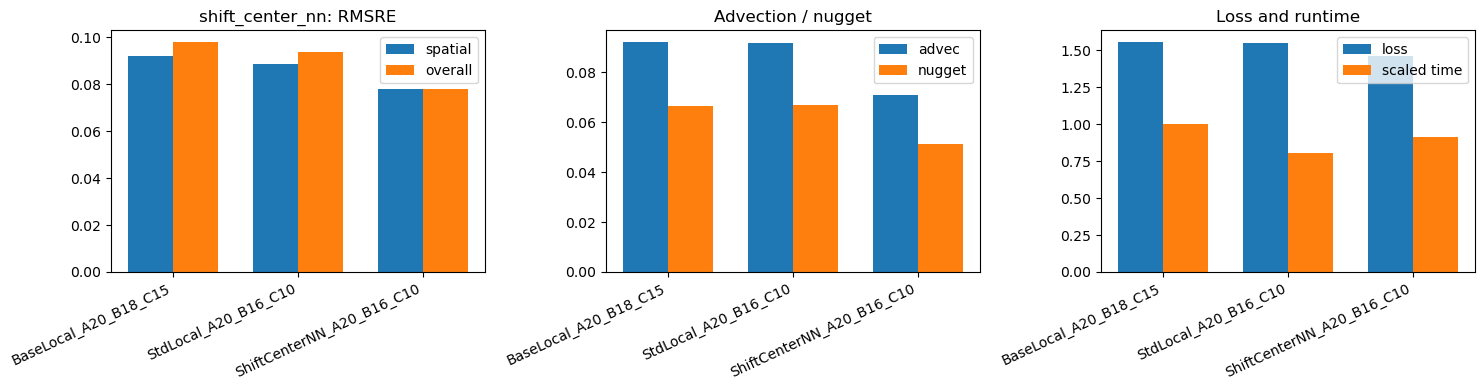

In [10]:
for group, sub in mc_summary.groupby("group", sort=False):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    x = np.arange(len(sub))
    labels = sub["model"].to_list()

    axes[0].bar(x - 0.18, sub["spatial_rmsre_mean"], width=0.36, label="spatial")
    axes[0].bar(x + 0.18, sub["overall_rmsre_mean"], width=0.36, label="overall")
    axes[0].set_title(f"{group}: RMSRE")
    axes[0].set_xticks(x, labels, rotation=25, ha="right")
    axes[0].legend()

    axes[1].bar(x - 0.18, sub["advec_rmsre_mean"], width=0.36, label="advec")
    axes[1].bar(x + 0.18, sub["nugget_re_mean"], width=0.36, label="nugget")
    axes[1].set_title("Advection / nugget")
    axes[1].set_xticks(x, labels, rotation=25, ha="right")
    axes[1].legend()

    axes[2].bar(x - 0.18, sub["loss_mean"], width=0.36, label="loss")
    axes[2].bar(x + 0.18, sub["total_s_mean"] / max(sub["total_s_mean"].max(), 1), width=0.36, label="scaled time")
    axes[2].set_title("Loss and runtime")
    axes[2].set_xticks(x, labels, rotation=25, ha="right")
    axes[2].legend()

    plt.tight_layout()
    plt.show()


## Diagnostic Decision Rule


In [11]:
print("Decision rule:")
print("1. Compare StdLocal_A20_B16_C10 vs ShiftCenterNN_A20_B16_C10 to isolate shifted-center value at nearly the same reduced budget; ShiftCenter has two extra upstream-center anchor slots.")
print("2. Compare ShiftCenterNN_A20_B16_C10 vs BaseLocal_A20_B18_C15 to see whether advection-aware centering can beat or tie the current best reduced baseline with fewer total conditioning slots.")
display(spec_df[["limit_A", "limit_B", "limit_C", "kernel", "advec_lon_offset", "lag1_lon_shift", "lag2_lon_shift", "total_conditioning", "allocation"]])


Decision rule:
1. Compare StdLocal_A20_B16_C10 vs ShiftCenterNN_A20_B16_C10 to isolate shifted-center value at nearly the same reduced budget; ShiftCenter has two extra upstream-center anchor slots.
2. Compare ShiftCenterNN_A20_B16_C10 vs BaseLocal_A20_B18_C15 to see whether advection-aware centering can beat or tie the current best reduced baseline with fewer total conditioning slots.


,limit_A,limit_B,limit_C,kernel,advec_lon_offset,lag1_lon_shift,lag2_lon_shift,total_conditioning,allocation
shift_center_nn::BaseLocal_A20_B18_C15,20,18,15,std,0.0,0.0,0.0,55,best local-only reduced baseline: 20/18/15
shift_center_nn::StdLocal_A20_B16_C10,20,16,10,std,0.0,0.0,0.0,48,local-only aggressive reduction control: 20/16/10
shift_center_nn::ShiftCenterNN_A20_B16_C10,20,16,10,advec_center,0.126,0.126,0.252,50,fresh lagged NN search around true upstream ce...


## Interpretation

This is a simulation-only oracle experiment. The longitude grid spacing is `0.126`, matching the one-step upstream displacement implied by `advec_lon = -0.126`. Unlike the earlier true-shift experiment, this notebook does not translate the current-time neighbor list. Instead, it performs a new nearest-neighbor search around the upstream center at each lag.

A useful outcome is not only beating `20/18/15`; it is also enough for `ShiftCenterNN_A20_B16_C10` to substantially beat `StdLocal_A20_B16_C10`, because that would show that the extra structure is really coming from advection-aware lag selection rather than just random budget noise.

If a shifted upstream point leaves the longitude range, the kernel falls back to the same spatial location, matching the boundary convention used in the previous true-shift diagnostic.
